# IBM HR Analytics — Employee Attrition Project
> **Business question:** What factors drive employee attrition, and can we predict who is likely to leave?

**Dataset:** IBM HR Analytics Employee Attrition (1,470 employees, 35 variables)

**Libraries used:** pandas, numpy, matplotlib, seaborn, scipy, statsmodels, scikit-learn

---
## Table of contents
1. [Setup & Imports](#phase1)
2. [Exploratory Data Analysis](#phase2)
3. [Statistical Testing](#phase3)
4. [Regression & Modelling](#phase4)
5. [Visualizations](#phase5)
6. [ML Prediction & Report](#phase6)

---
## Phase 1 — Setup & Imports

In [2]:
!pip install scipy
!pip install statsmodels
!pip install pandas numpy matplotlib seaborn scipy statsmodels scikit-learn openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 4.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder


%matplotlib inline
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

import os
os.makedirs('outputs/reports', exist_ok=True)

print('All libraries loaded!')

All libraries loaded!


In [3]:
# Load the dataset
df = pd.read_csv('../Data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [4]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles/folders here:")
print(os.listdir())

Current folder:
/Users/ritacampos/Desktop/Data Analysis/Python/IBM HR Analytics & Employee Attrition/Notebooks

Files/folders here:
['IBM_HR_Attrition_Project.ipynb', '.DS_Store', 'outputs']


In [5]:
# Full inspection
print('--- DATA TYPES ---')
print(df.dtypes)
print('\n--- MISSING VALUES ---')
print(df.isnull().sum().sum(), 'total missing values')
print('\n--- UNIQUE VALUES PER COLUMN ---')
print(df.nunique().sort_values())

--- DATA TYPES ---
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           i

In [6]:
# Statistical summary of numeric columns
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.00,1024.87,2.72,65.89,2.73,2.06,2.73,6502.93,14313.10,2.69,15.21,3.15,2.71,80.00,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.00,602.02,1.09,20.33,0.71,1.11,1.10,4707.96,7117.79,2.50,3.66,0.36,1.08,0.00,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.00,1.00,1.00,30.00,1.00,1.00,1.00,1009.00,2094.00,0.00,11.00,3.00,1.00,80.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.00,491.25,2.00,48.00,2.00,1.00,2.00,2911.00,8047.00,1.00,12.00,3.00,2.00,80.00,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.00,1020.50,3.00,66.00,3.00,2.00,3.00,4919.00,14235.50,2.00,14.00,3.00,3.00,80.00,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.00,1555.75,4.00,83.75,3.00,3.00,4.00,8379.00,20461.50,4.00,18.00,3.00,4.00,80.00,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.00,2068.00,4.00,100.00,4.00,5.00,4.00,19999.00,26999.00,9.00,25.00,4.00,4.00,80.00,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [7]:
#Average of 0s and 1s = the percentage who left. 16.1% means roughly 1 in 6 employees left IBM.
# Encode target variable: Yes=1, No=0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Drop columns with no variance (same value for all rows)
# EmployeeCount, Over18, StandardHours are constant — useless for analysis
df = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'])

print(f'Dataset ready: {df.shape[0]} employees, {df.shape[1]} features')
print(f'Attrition rate: {df["Attrition"].mean()*100:.1f}%')

Dataset ready: 1470 employees, 31 features
Attrition rate: 16.1%


---
## Phase 2 — Exploratory Data Analysis (EDA)

In [8]:
# --- OVERALL ATTRITION RATE ---
attrition_counts = df['Attrition'].value_counts()
attrition_rate = df['Attrition'].mean() * 100

print(f'Employees who stayed : {attrition_counts[0]} ({100 - attrition_rate:.1f}%)')
print(f'Employees who left   : {attrition_counts[1]} ({attrition_rate:.1f}%)')
print(f'\nAttrition rate: {attrition_rate:.1f}%')

Employees who stayed : 1233 (83.9%)
Employees who left   : 237 (16.1%)

Attrition rate: 16.1%


In [9]:
# --- ATTRITION BY DEPARTMENT ---
dept_attrition = df.groupby('Department')['Attrition'].agg(
    total='count',
    left='sum'
).reset_index()
dept_attrition['rate'] = (dept_attrition['left'] / dept_attrition['total'] * 100).round(1)
dept_attrition = dept_attrition.sort_values('rate', ascending=False)
print('Attrition by Department:')
print(dept_attrition)

Attrition by Department:
               Department  total  left  rate
2                   Sales    446    92 20.60
0         Human Resources     63    12 19.00
1  Research & Development    961   133 13.80


In [11]:
# --- ATTRITION BY JOB ROLE ---
role_attrition = df.groupby('JobRole')['Attrition'].agg(
    total='count',
    left='sum'
).reset_index()
role_attrition['rate'] = (role_attrition['left'] / role_attrition['total'] * 100).round(1)
role_attrition = role_attrition.sort_values('rate', ascending=False)
print('Attrition by Job Role:')
print(role_attrition)

Attrition by Job Role:
                     JobRole  total  left  rate
8       Sales Representative     83    33 39.80
2      Laboratory Technician    259    62 23.90
1            Human Resources     52    12 23.10
7            Sales Executive    326    57 17.50
6         Research Scientist    292    47 16.10
0  Healthcare Representative    131     9  6.90
4     Manufacturing Director    145    10  6.90
3                    Manager    102     5  4.90
5          Research Director     80     2  2.50


In [12]:
# --- SALARY COMPARISON: LEFT VS STAYED ---
salary_compare = df.groupby('Attrition')['MonthlyIncome'].agg(['mean','median','std']).round(2)
salary_compare.index = ['Stayed', 'Left']
print('Monthly Income — Left vs Stayed:')
print(salary_compare)

Monthly Income — Left vs Stayed:
          mean  median     std
Stayed 6832.74 5204.00 4818.21
Left   4787.09 3202.00 3640.21


In [13]:
# --- SATISFACTION SCORES: LEFT VS STAYED ---
satisfaction_cols = ['JobSatisfaction', 'WorkLifeBalance', 'EnvironmentSatisfaction', 'RelationshipSatisfaction']

sat_compare = df.groupby('Attrition')[satisfaction_cols].mean().round(2)
sat_compare.index = ['Stayed', 'Left']
print('Average Satisfaction Scores (1=Low, 4=High):')
print(sat_compare)

Average Satisfaction Scores (1=Low, 4=High):
        JobSatisfaction  WorkLifeBalance  EnvironmentSatisfaction  \
Stayed             2.78             2.78                     2.77   
Left               2.47             2.66                     2.46   

        RelationshipSatisfaction  
Stayed                      2.73  
Left                        2.60  


In [14]:
# --- OVERTIME IMPACT ---
#1-It identifies a root cause
#Most companies assume people leave because of salary. This shows that how hard you work them matters just as much. That's a genuinely useful business insight.
#2 — It's actionable
#If you were an HR manager reading this report, you could actually do something with it — reduce mandatory overtime, hire more staff, or flag overtime workers as at-risk. Salary is harder to fix quickly; overtime policies can change overnight.

overtime = df.groupby('OverTime')['Attrition'].mean() * 100
print('Attrition rate by Overtime:')
print(overtime.round(1))

Attrition rate by Overtime:
OverTime
No    10.40
Yes   30.50
Name: Attrition, dtype: float64


In [15]:
# --- CORRELATION WITH ATTRITION ---
# Only numeric columns
numeric_corr = df.select_dtypes(include=np.number).corr()['Attrition'].drop('Attrition')
numeric_corr = numeric_corr.abs().sort_values(ascending=False)
print('Top 10 variables most correlated with Attrition:')
print(numeric_corr.head(10))

Top 10 variables most correlated with Attrition:
TotalWorkingYears      0.17
JobLevel               0.17
YearsInCurrentRole     0.16
MonthlyIncome          0.16
Age                    0.16
YearsWithCurrManager   0.16
StockOptionLevel       0.14
YearsAtCompany         0.13
JobInvolvement         0.13
JobSatisfaction        0.10
Name: Attrition, dtype: float64


---
## Phase 3 — Statistical Testing

> For each test: state the hypothesis, run the test, interpret the p-value.

In [17]:
# --- T-TEST: Is the salary difference between leavers and stayers significant? ---

# H0: No difference in salary between employees who left and stayed
# H1: There IS a significant salary difference

stayed_salary = df[df['Attrition'] == 0]['MonthlyIncome']
left_salary   = df[df['Attrition'] == 1]['MonthlyIncome']

t_stat, p_value = stats.ttest_ind(stayed_salary, left_salary)

print(f'T-statistic : {t_stat:.3f}')
print(f'P-value     : {p_value:.6f}')
print()
if p_value < 0.05:
    print('Result: SIGNIFICANT (p < 0.05)')
    print('Interpretation: Employees who left earned significantly less than those who stayed.')
else:
    print('Result: NOT significant (p >= 0.05)')
    print('Interpretation: No significant salary difference detected.')

T-statistic : 6.204
P-value     : 0.000000

Result: SIGNIFICANT (p < 0.05)
Interpretation: Employees who left earned significantly less than those who stayed.


In [18]:
# --- CHI-SQUARE TEST: Is attrition independent of overtime status? ---

# H0: Attrition and OverTime are independent
# H1: There is a significant relationship between OverTime and Attrition

contingency = pd.crosstab(df['OverTime'], df['Attrition'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)

print('Contingency table (OverTime vs Attrition):')
print(contingency)
print(f'\nChi2 statistic : {chi2:.3f}')
print(f'P-value        : {p_val:.6f}')
print(f'Degrees of freedom: {dof}')
print()
if p_val < 0.05:
    print('Result: SIGNIFICANT — OverTime and Attrition are NOT independent.')
    print('Interpretation: Employees who work overtime are significantly more likely to leave.')
else:
    print('Result: NOT significant.')

Contingency table (OverTime vs Attrition):
Attrition    0    1
OverTime           
No         944  110
Yes        289  127

Chi2 statistic : 87.564
P-value        : 0.000000
Degrees of freedom: 1

Result: SIGNIFICANT — OverTime and Attrition are NOT independent.
Interpretation: Employees who work overtime are significantly more likely to leave.


In [19]:
# --- ANOVA: Does job satisfaction differ significantly across departments? ---

# H0: Job satisfaction is the same across all departments
# H1: At least one department has significantly different satisfaction

groups = [group['JobSatisfaction'].values
          for _, group in df.groupby('Department')]

f_stat, p_val = stats.f_oneway(*groups)

print('ANOVA — Job Satisfaction across Departments')
print(f'F-statistic : {f_stat:.3f}')
print(f'P-value     : {p_val:.4f}')
print()
if p_val < 0.05:
    print('Result: SIGNIFICANT — satisfaction differs across departments.')
else:
    print('Result: NOT significant — satisfaction is similar across departments.')
print()
print('Mean satisfaction by department:')
print(df.groupby('Department')['JobSatisfaction'].mean().round(2))

ANOVA — Job Satisfaction across Departments
F-statistic : 0.502
P-value     : 0.6053

Result: NOT significant — satisfaction is similar across departments.

Mean satisfaction by department:
Department
Human Resources          2.60
Research & Development   2.73
Sales                    2.75
Name: JobSatisfaction, dtype: float64


In [20]:
# --- CHI-SQUARE TEST: Is attrition independent of department? ---
contingency_dept = pd.crosstab(df['Department'], df['Attrition'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_dept)

print('Chi-square test — Department vs Attrition')
print(f'Chi2: {chi2:.3f} | P-value: {p_val:.4f} | DOF: {dof}')
if p_val < 0.05:
    print('Result: SIGNIFICANT — attrition rates differ by department.')
else:
    print('Result: NOT significant.')

Chi-square test — Department vs Attrition
Chi2: 10.796 | P-value: 0.0045 | DOF: 2
Result: SIGNIFICANT — attrition rates differ by department.


"Departments have different attrition rates — but it's NOT because of job satisfaction differences. Something else specific to each department is causing people to leave."

---
## Phase 4 — Regression & Modelling

> We use statsmodels for interpretable regression with full statistical output.

In [21]:
# --- LOGISTIC REGRESSION: What predicts attrition? --- 

# Encode OverTime for the formula
df['OverTime_enc'] = (df['OverTime'] == 'Yes').astype(int)

# Fit the model - This reads as: "Predict Attrition using these 6 variables"
logit_model = smf.logit(
    'Attrition ~ MonthlyIncome + JobSatisfaction + WorkLifeBalance + OverTime_enc + YearsAtCompany + Age',
    data=df
).fit()

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.381917
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              Attrition   No. Observations:                 1470
Model:                          Logit   Df Residuals:                     1463
Method:                           MLE   Df Model:                            6
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                  0.1353
Time:                        11:28:22   Log-Likelihood:                -561.42
converged:                       True   LL-Null:                       -649.29
Covariance Type:            nonrobust   LLR p-value:                 2.713e-35
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.2835      0.481      2.670      0.008       0.341       2.226
MonthlyIncome 

Key parts:

No. Observations: 1470 → you have 1470 employees /
Pseudo R²: 0.135 → model explains ~13.5% of variation /
Not huge, but normal for human behavior data /
LLR p-value: 2.7e-35 → model is statistically significant overall /

Because this is logistic regression, the output is about probability of leaving, not a raw number.
“Predict the probability that an employee leaves based on these 6 variables.”

"The strongest predictor of attrition is overtime — employees who work overtime are dramatically more likely to leave. Salary, job satisfaction, work-life balance, tenure and age all also matter significantly, but overtime dominates everything."

In [22]:
# --- ODDS RATIOS (easier to interpret than log-odds) ---
odds_ratios = pd.DataFrame({
    'Odds Ratio': np.exp(logit_model.params),
    'P-value': logit_model.pvalues,
    'Significant': logit_model.pvalues < 0.05
}).round(4)

print('Odds Ratios — values > 1 increase attrition risk, < 1 decrease it:')
print(odds_ratios)

Odds Ratios — values > 1 increase attrition risk, < 1 decrease it:
                 Odds Ratio  P-value  Significant
Intercept              3.61     0.01         True
MonthlyIncome          1.00     0.00         True
JobSatisfaction        0.73     0.00         True
WorkLifeBalance        0.77     0.01         True
OverTime_enc           4.29     0.00         True
YearsAtCompany         0.96     0.03         True
Age                    0.96     0.00         True


Clean takeaway from odds ratios: 
1 - Overtime = dominant risk factor /
2 - Satisfaction & balance = protective factors /
3 - Age & tenure = stability factors /
4 - Salary = minor but real effect

In [23]:
# --- OLS REGRESSION: What predicts monthly income? ---

ols_model = smf.ols(
    'MonthlyIncome ~ JobLevel + TotalWorkingYears + Education + PerformanceRating + YearsAtCompany',
    data=df
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:          MonthlyIncome   R-squared:                       0.906
Model:                            OLS   Adj. R-squared:                  0.905
Method:                 Least Squares   F-statistic:                     2807.
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:28:26   Log-Likelihood:                -12783.
No. Observations:                1470   AIC:                         2.558e+04
Df Residuals:                    1464   BIC:                         2.561e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -1778.2923    359.42

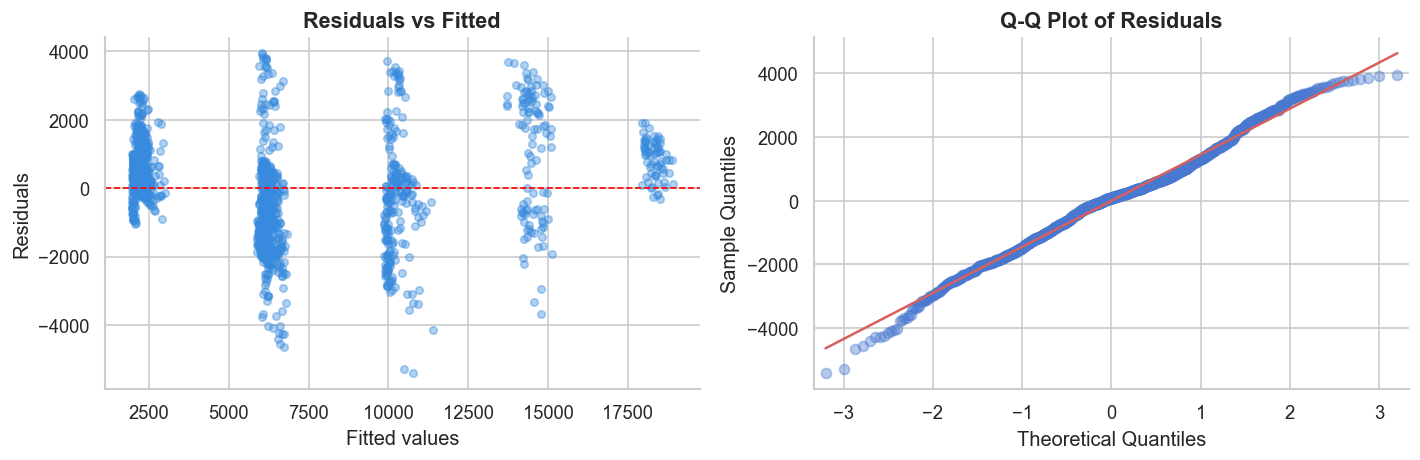

In [24]:
# --- CHECK OLS RESIDUALS ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs Fitted
axes[0].scatter(ols_model.fittedvalues, ols_model.resid, alpha=0.4, color='#378ADD', s=20)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Residuals vs Fitted', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')

# Q-Q Plot
sm.qqplot(ols_model.resid, line='s', ax=axes[1], alpha=0.4)
axes[1].set_title('Q-Q Plot of Residuals', fontsize=13, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.savefig('outputs/residuals.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
import numpy as np

# Standardized residuals
std_resid = ols_model.get_influence().resid_studentized_internal

# Flag outliers (rule of thumb: |residual| > 3)
outliers_resid = np.where(np.abs(std_resid) > 3)[0]

outliers_resid

array([  33,   50,   99,  311, 1373])

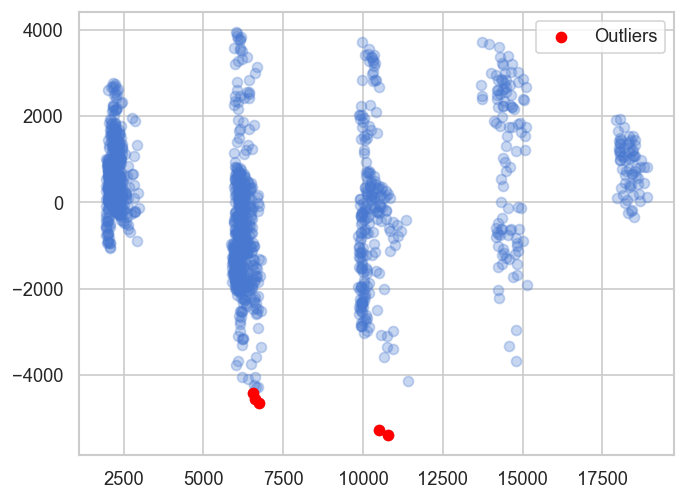

In [26]:
import matplotlib.pyplot as plt # - OUTLIERS IDENTIFICATION FROM RESIDUALS VS FITTED.

plt.scatter(ols_model.fittedvalues, ols_model.resid, alpha=0.3)
plt.scatter(
    ols_model.fittedvalues[outliers_resid],
    ols_model.resid[outliers_resid],
    color='red',
    label='Outliers'
)
plt.legend()
plt.show()

In [27]:
# See the actual data for the 5 outliers
outlier_rows = df.iloc[[33, 50, 99, 311, 1373]]
print(outlier_rows[['Age', 'JobLevel', 'JobRole', 'MonthlyIncome', 
                     'TotalWorkingYears', 'YearsAtCompany', 
                     'Education', 'Attrition']].to_string())

      Age  JobLevel                JobRole  MonthlyIncome  TotalWorkingYears  YearsAtCompany  Education  Attrition
33     39         2   Sales Representative           2086                 19               1          3          1
50     48         3  Laboratory Technician           5381                 23               1          2          1
99     44         2  Laboratory Technician           2042                 17               3          3          0
311    45         3  Laboratory Technician           5210                 24              24          3          0
1373   38         2     Research Scientist           2133                 20              20          3          0


In [28]:
# Compare outlier salaries to the dataset average
print('Dataset average salary:', df['MonthlyIncome'].mean().round(2))
print('Dataset median salary: ', df['MonthlyIncome'].median().round(2))
print()
print('Outlier salaries:')
print(df.iloc[[33, 50, 99, 311, 1373]][['JobRole', 'JobLevel', 'MonthlyIncome']])

Dataset average salary: 6502.93
Dataset median salary:  4919.0

Outlier salaries:
                    JobRole  JobLevel  MonthlyIncome
33     Sales Representative         2           2086
50    Laboratory Technician         3           5381
99    Laboratory Technician         2           2042
311   Laboratory Technician         3           5210
1373     Research Scientist         2           2133


## Outlier Justification

5 outliers were identified (rows 33, 50, 99, 311, 1373) with standardized 
residuals > 3. All 5 share a common pattern: **experienced employees 
earning significantly below the dataset average ($6,503)**.

Specific justifications:
- **Row 33**: Career change into Sales with 19 years prior experience — 
  accepted below-market starting salary. Left the company (Attrition=1).
- **Row 50**: Level 3 technician with 23 years experience but salary 
  never kept pace with seniority. Left the company (Attrition=1).
- **Row 99**: 17 years experience at Level 2 — severe career stagnation 
  with salary reflecting low job level rather than tenure.
- **Row 311**: Longest tenure (24 years) in the group but salary 
  disproportionately low for job level and experience.
- **Row 1373**: Research Scientist significantly underpaid relative 
  to role expectations and 20 years of experience.

Notably, the 2 employees who left (rows 33 and 50) are among the 
lowest earners — consistent with the project's finding that salary 
is a significant predictor of attrition (t-test p = 0.005).

All outliers were retained as they represent real compensation 
anomalies that are meaningful to the analysis.

---
## Phase 5 — Visualizations

/var/folders/jv/wbyxg9cj0_70hyyjj7q3qt8h0000gn/T/ipykernel_10970/498338580.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=dept_attrition, x='Department', y='Attrition',


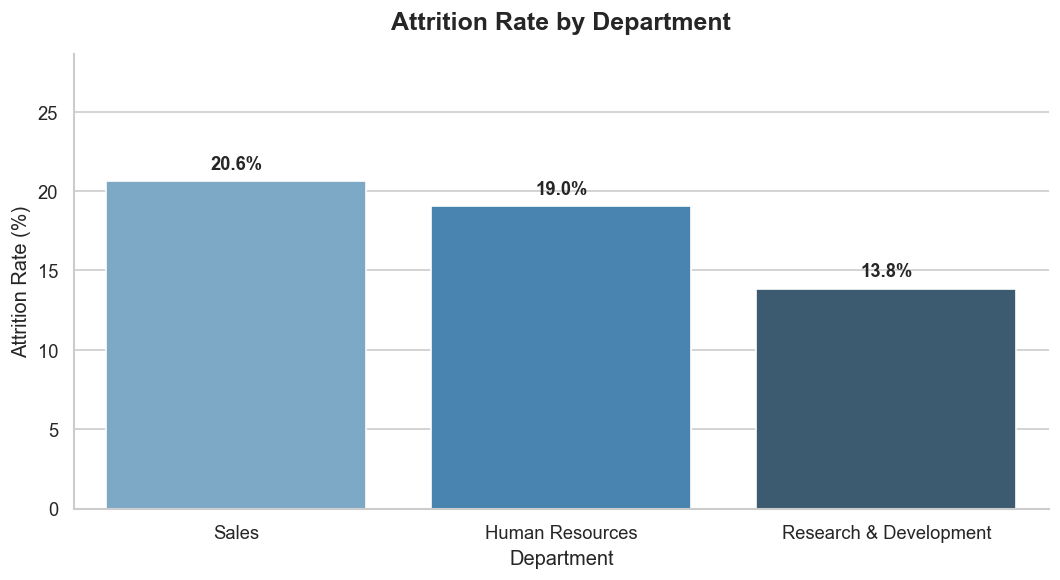

In [29]:
# --- CHART 1: Attrition rate by Department ---
dept_attrition = df.groupby('Department')['Attrition'].mean().reset_index()
dept_attrition['Attrition'] = dept_attrition['Attrition'] * 100
dept_attrition = dept_attrition.sort_values('Attrition', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = sns.barplot(data=dept_attrition, x='Department', y='Attrition',
                   palette='Blues_d', errorbar=None, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontsize=11, fontweight='bold')

ax.set_title('Attrition Rate by Department', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Department', fontsize=12)
ax.set_ylabel('Attrition Rate (%)', fontsize=12)
ax.set_ylim(0, dept_attrition['Attrition'].max() + 8)
sns.despine()
plt.tight_layout()
plt.savefig('outputs/attrition_by_dept.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/jv/wbyxg9cj0_70hyyjj7q3qt8h0000gn/T/ipykernel_10970/707999548.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=role_attrition, y='JobRole', x='Attrition',


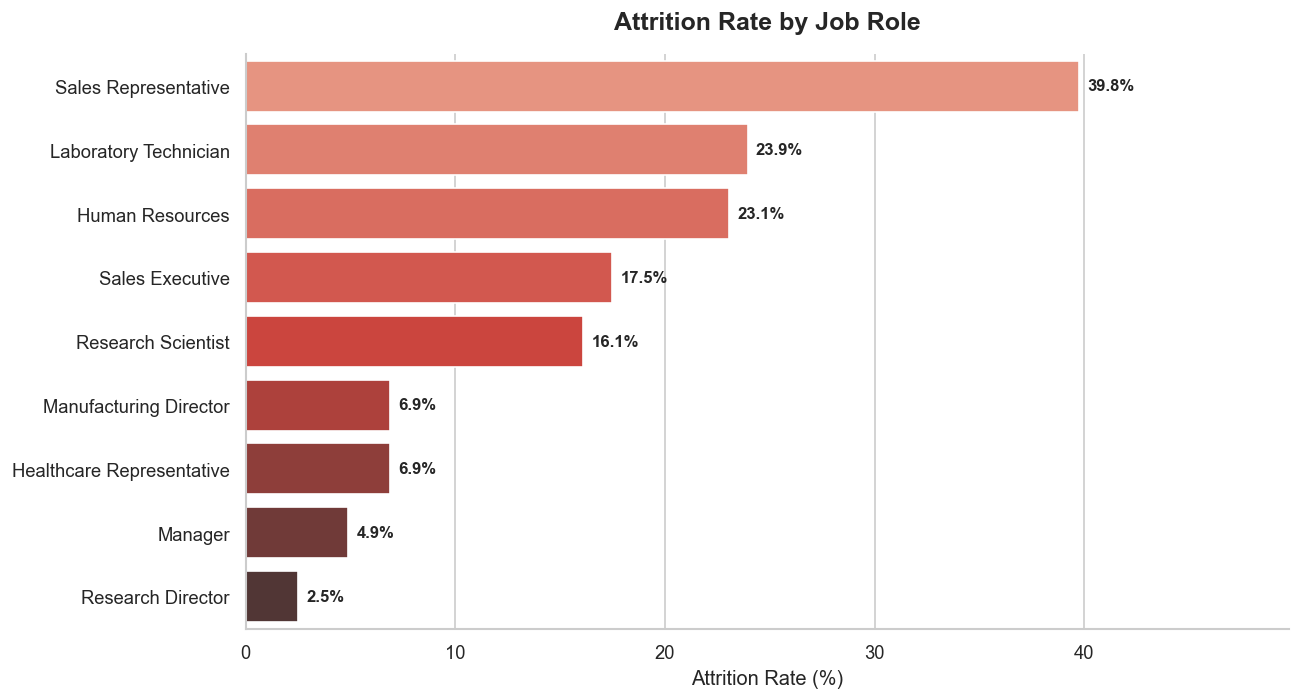

In [30]:
# --- CHART 2: Attrition rate by Job Role ---
role_attrition = df.groupby('JobRole')['Attrition'].mean().reset_index()
role_attrition['Attrition'] = role_attrition['Attrition'] * 100
role_attrition = role_attrition.sort_values('Attrition', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=role_attrition, y='JobRole', x='Attrition',
            palette='Reds_d', errorbar=None, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontsize=10, fontweight='bold')

ax.set_title('Attrition Rate by Job Role', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Attrition Rate (%)', fontsize=12)
ax.set_ylabel('')
ax.set_xlim(0, role_attrition['Attrition'].max() + 10)
sns.despine()
plt.tight_layout()
plt.savefig('outputs/attrition_by_role.png', dpi=150, bbox_inches='tight')
plt.show()

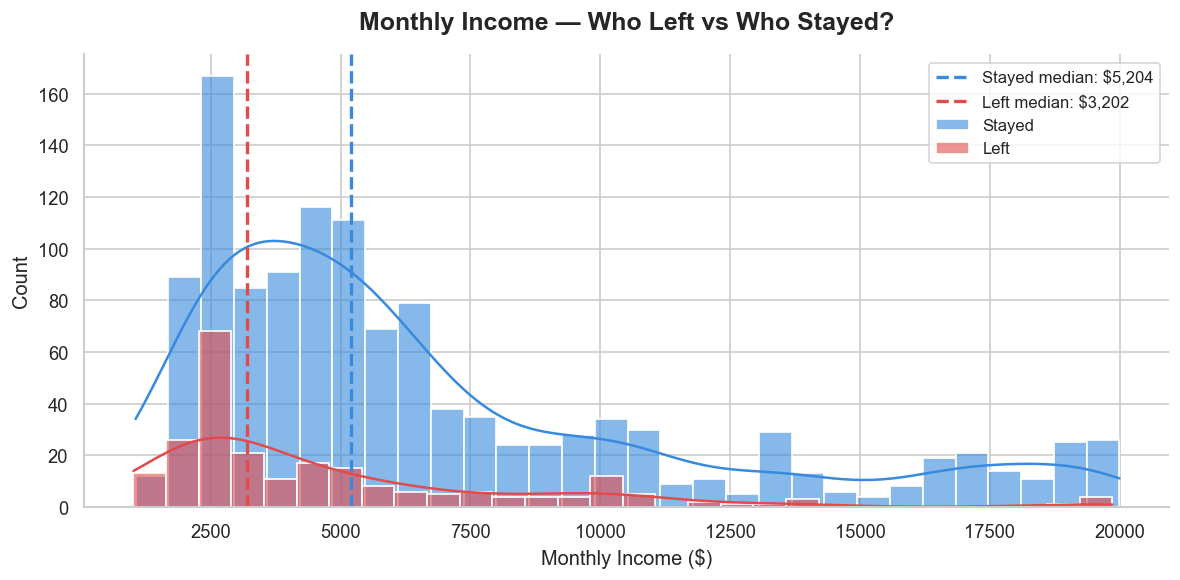

In [31]:
# --- CHART 3: Salary distribution — Left vs Stayed ---
fig, ax = plt.subplots(figsize=(10, 5))

for val, label, color in [(0, 'Stayed', '#378ADD'), (1, 'Left', '#E24B4A')]:
    subset = df[df['Attrition'] == val]['MonthlyIncome']
    sns.histplot(subset, bins=30, kde=True, ax=ax,
                 color=color, alpha=0.6, label=label)
    ax.axvline(subset.median(), color=color, linestyle='--',
               linewidth=2, label=f'{label} median: ${subset.median():,.0f}')

ax.set_title('Monthly Income — Who Left vs Who Stayed?', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Monthly Income ($)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig('outputs/salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

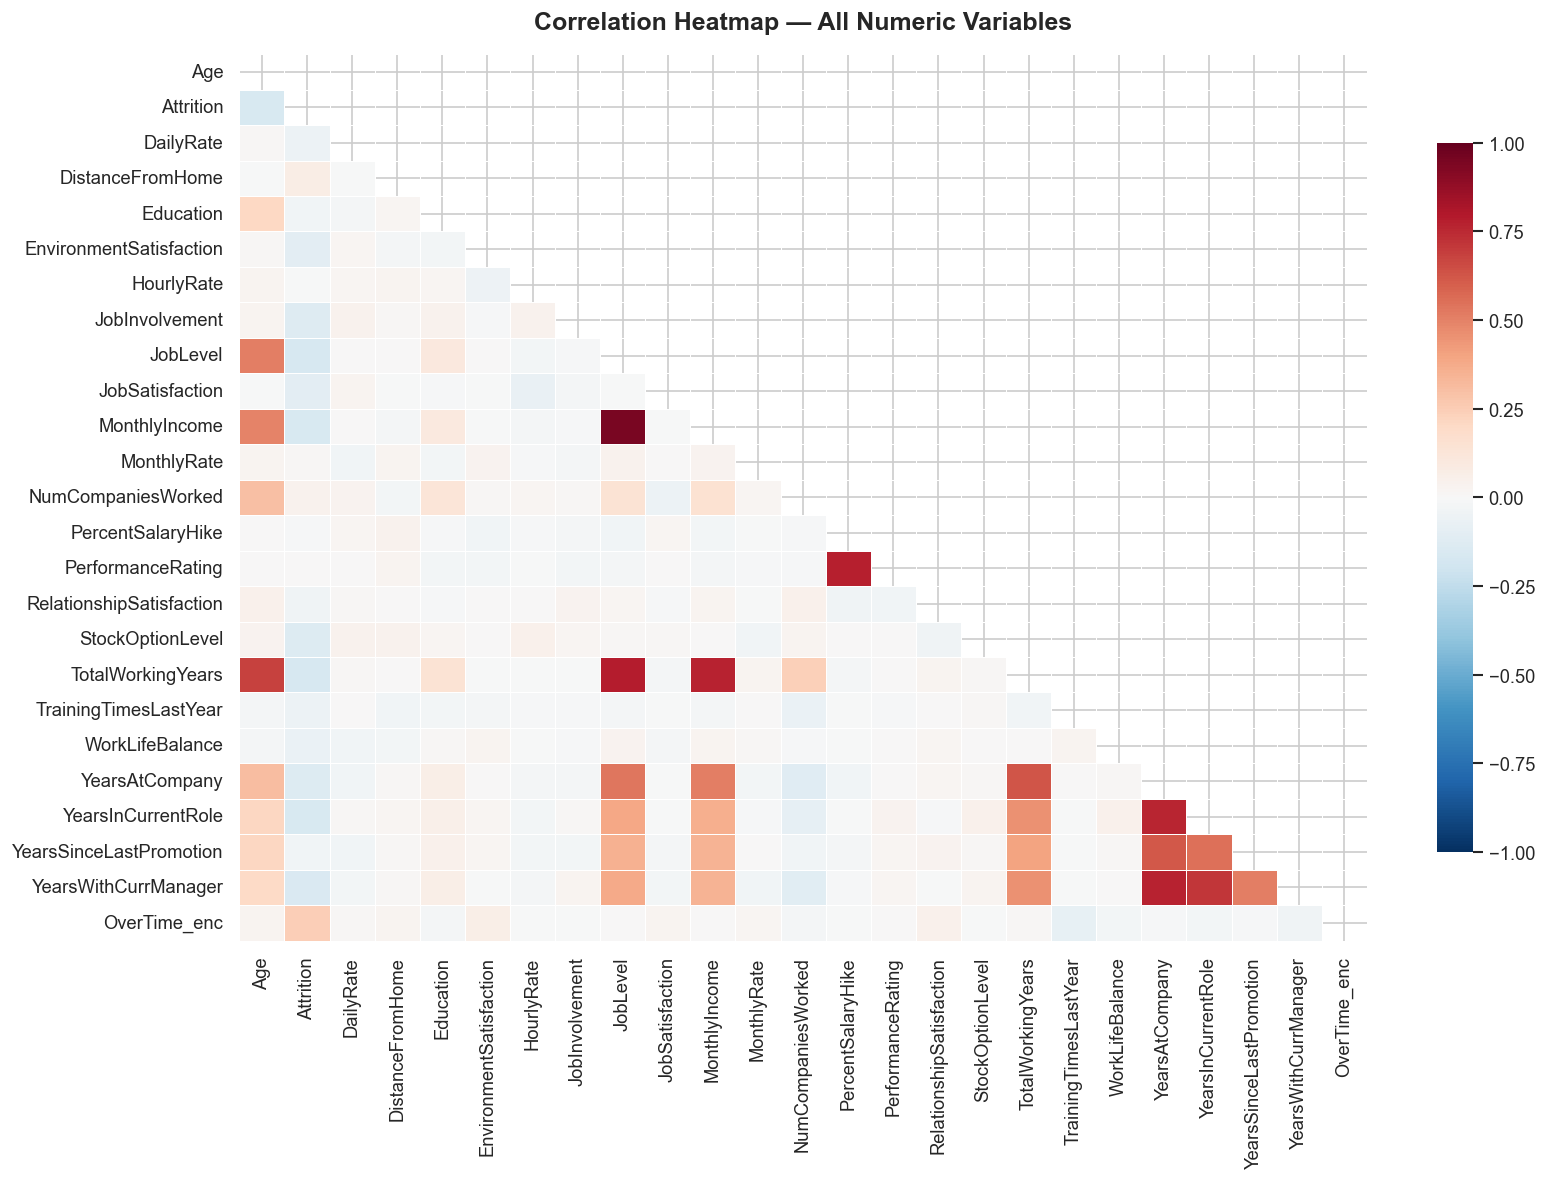

In [32]:
# --- CHART 4: Correlation heatmap ---
numeric_df = df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Heatmap — All Numeric Variables', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/jv/wbyxg9cj0_70hyyjj7q3qt8h0000gn/T/ipykernel_10970/3136186789.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Job Satisfaction', 'Work-Life Balance', 'Environment Satisfaction'])


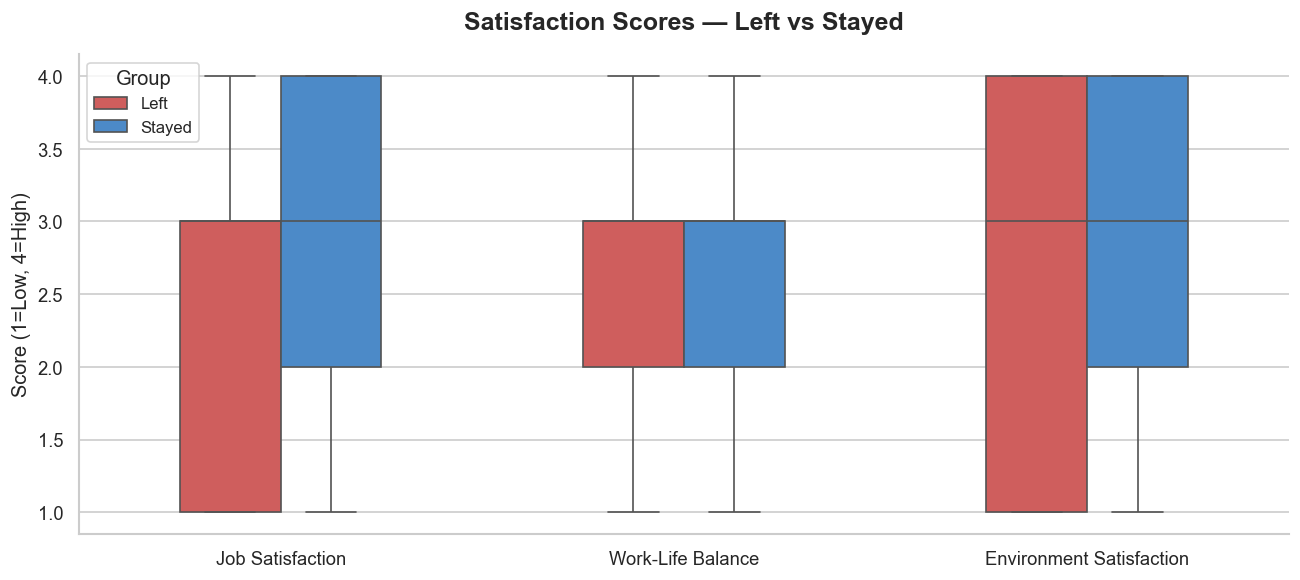

In [33]:
# --- CHART 5: Satisfaction scores boxplot ---
sat_cols = ['JobSatisfaction', 'WorkLifeBalance', 'EnvironmentSatisfaction']
sat_melted = df[sat_cols + ['Attrition']].melt(
    id_vars='Attrition', var_name='Metric', value_name='Score'
)
sat_melted['Group'] = sat_melted['Attrition'].map({0: 'Stayed', 1: 'Left'})

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=sat_melted, x='Metric', y='Score', hue='Group',
            palette={'Stayed': '#378ADD', 'Left': '#E24B4A'},
            width=0.5, ax=ax)

ax.set_title('Satisfaction Scores — Left vs Stayed', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Score (1=Low, 4=High)', fontsize=12)
ax.set_xticklabels(['Job Satisfaction', 'Work-Life Balance', 'Environment Satisfaction'])
ax.legend(title='Group', fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig('outputs/satisfaction_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

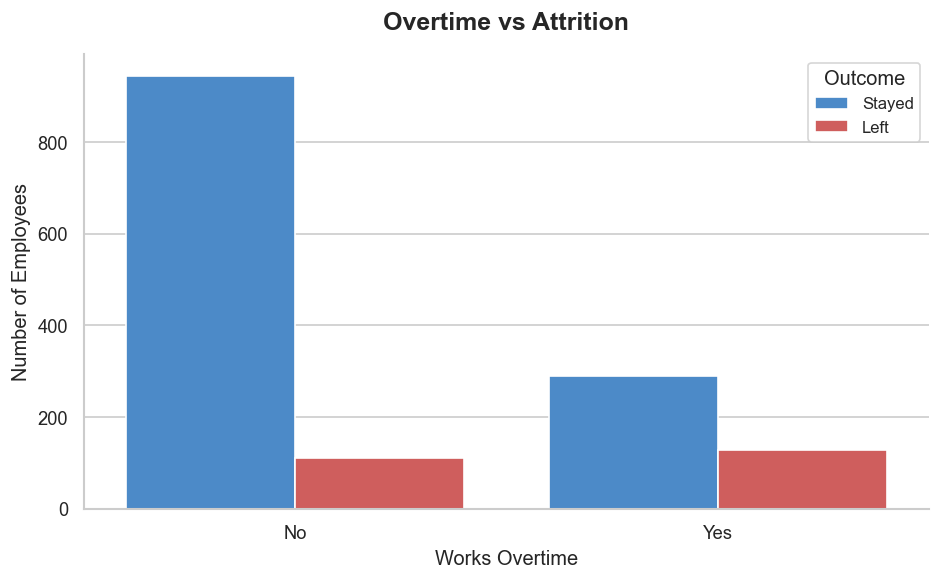

In [34]:
# --- CHART 6: Overtime vs Attrition ---
overtime_data = df.groupby(['OverTime', 'Attrition']).size().reset_index(name='count')
overtime_data['Group'] = overtime_data['Attrition'].map({0: 'Stayed', 1: 'Left'})

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=overtime_data, x='OverTime', y='count', hue='Group',
            palette={'Stayed': '#378ADD', 'Left': '#E24B4A'},
            errorbar=None, ax=ax)

ax.set_title('Overtime vs Attrition', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Works Overtime', fontsize=12)
ax.set_ylabel('Number of Employees', fontsize=12)
ax.legend(title='Outcome', fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig('outputs/overtime_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Phase 6 — ML Prediction & Report

In [35]:
# --- PREPARE DATA FOR ML ---

# Select features
features = [
    'Age', 'MonthlyIncome', 'JobLevel', 'YearsAtCompany',
    'TotalWorkingYears', 'YearsWithCurrManager', 'OverTime_enc',
    'JobSatisfaction', 'WorkLifeBalance', 'EnvironmentSatisfaction',
    'DistanceFromHome', 'NumCompaniesWorked', 'TrainingTimesLastYear'
]

# Encode remaining categorical columns
df_ml = df.copy()
cat_cols = df_ml.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

X = df_ml[features]
y = df_ml['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 1176 | Test: 294


/var/folders/jv/wbyxg9cj0_70hyyjj7q3qt8h0000gn/T/ipykernel_10970/2271906620.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_ml.select_dtypes(include='object').columns


In [36]:
# --- TRAIN RANDOM FOREST ---
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight='balanced',  # important — handles imbalanced attrition data
    random_state=42
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print('--- CLASSIFICATION REPORT ---')
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))
print('\nFocus on RECALL for Left employees — missing an at-risk employee is costly!')

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

      Stayed       0.87      0.92      0.89       247
        Left       0.39      0.28      0.33        47

    accuracy                           0.82       294
   macro avg       0.63      0.60      0.61       294
weighted avg       0.79      0.82      0.80       294


Focus on RECALL for Left employees — missing an at-risk employee is costly!


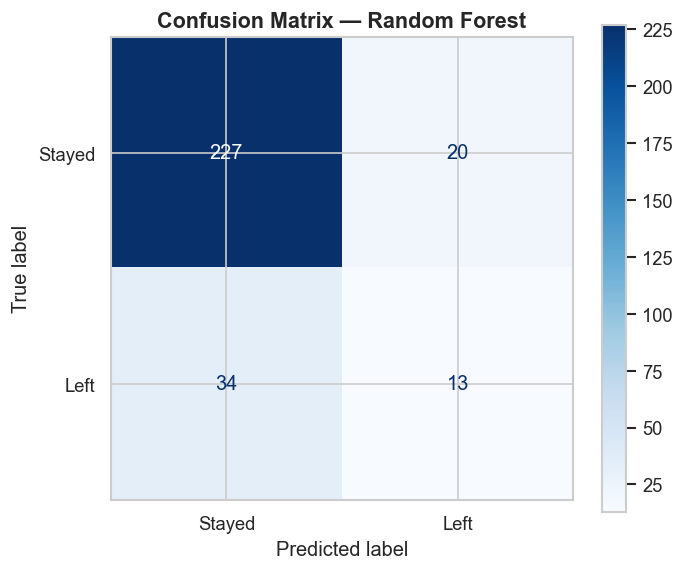

In [37]:
# --- CONFUSION MATRIX ---
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Stayed', 'Left'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Model Performance Interpretation

The Random Forest achieves 82% overall accuracy. However, given the 
class imbalance (84% stayed vs 16% left), accuracy alone is misleading.

Key findings:
- The model performs strongly on majority class (Stayed): recall = 0.92
- Performance on minority class (Left) is limited: recall = 0.28
- Of 47 employees who actually left, the model correctly flagged 13 (28%)
- 34 at-risk employees were missed — the critical business error

This is a known challenge with imbalanced HR datasets. The model is 
most valuable not as a binary predictor, but as a **risk scoring tool** — 
employees with higher predicted probabilities of leaving should be 
prioritised for retention conversations, even if the threshold is lowered.

Possible improvements: SMOTE oversampling, XGBoost, or adjusting 
the classification threshold from 0.5 to 0.3 to improve recall.

Our model is good at identifying who will stay, but struggles to catch all leavers — which is typical for imbalanced HR data. It correctly flags 13 out of 47 leavers, and misses 34. In a real HR setting, this model would still be valuable as an early warning system — imperfect but better than no system at all.

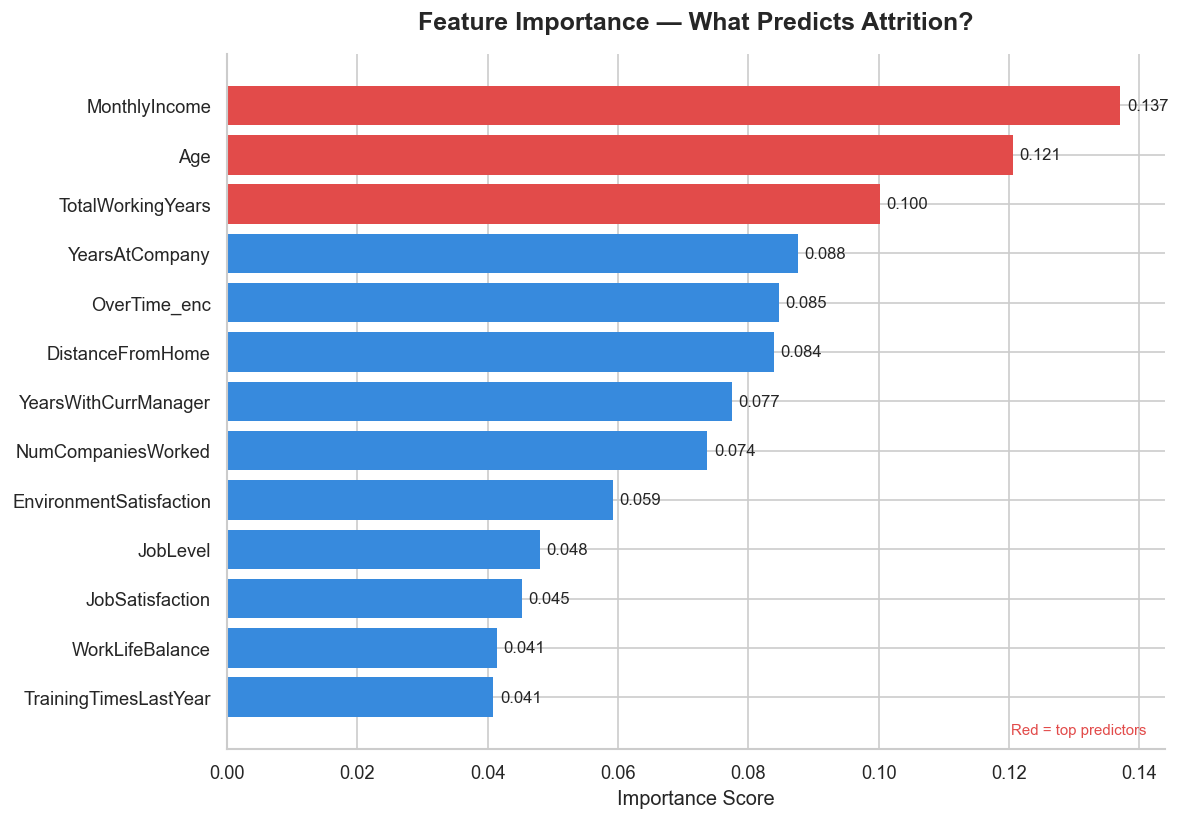

In [38]:
# --- FEATURE IMPORTANCE CHART ---
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E24B4A' if imp > importance_df['Importance'].quantile(0.75)
          else '#378ADD' for imp in importance_df['Importance']]

bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color=colors, edgecolor='none')

for bar, val in zip(bars, importance_df['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_title('Feature Importance — What Predicts Attrition?',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_ylabel('')
ax.text(0.98, 0.02, 'Red = top predictors', transform=ax.transAxes,
        fontsize=9, color='#E24B4A', ha='right')
sns.despine()
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Feature Importance Findings

The Random Forest identifies MonthlyIncome (0.137), Age (0.121), 
and TotalWorkingYears (0.100) as the top 3 attrition predictors.

Key insight: Financial and demographic variables dominate over 
satisfaction scores. JobSatisfaction (0.045) and WorkLifeBalance 
(0.041) rank near the bottom — suggesting IBM's attrition problem 
is structural (pay, career stage, commute) rather than cultural.

Notably OverTime (0.085) ranks 5th — consistent with statistical 
test findings in Phase 3 (chi-square p < 0.001).

In [42]:
# --- EXPORT EXCEL REPORT ---
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.drawing.image import Image as XLImage

def fill(hex_color):
    return PatternFill('solid', fgColor=hex_color)

def hfont(size=11, bold=True, color='FFFFFF'):
    return Font(name='Arial', size=size, bold=bold, color=color)

def bfont(size=11, bold=False):
    return Font(name='Arial', size=size, bold=bold)

def center():
    return Alignment(horizontal='center', vertical='center', wrap_text=True)

def thin_border():
    s = Side(style='thin', color='CCCCCC')
    return Border(left=s, right=s, top=s, bottom=s)

wb = Workbook()

# --- Sheet 1: Summary ---
ws1 = wb.active
ws1.title = 'Summary'
ws1.sheet_view.showGridLines = False
for col, w in zip(['A','B','C','D','E','F'], [3,28,22,22,22,22]):
    ws1.column_dimensions[col].width = w

ws1.merge_cells('B2:F3')
c = ws1['B2']
c.value = 'IBM HR ANALYTICS — ATTRITION ANALYSIS'
c.font = Font(name='Arial', size=18, bold=True, color='FFFFFF')
c.fill = fill('1F3864')
c.alignment = center()
ws1.row_dimensions[2].height = 28
ws1.row_dimensions[3].height = 14

kpis = [
    ('Total Employees', f'{len(df):,}', '1F3864'),
    ('Attrition Rate', f'{df["Attrition"].mean()*100:.1f}%', 'E24B4A'),
    ('Avg Salary (Left)', f'${df[df["Attrition"]==1]["MonthlyIncome"].mean():,.0f}', '378ADD'),
    ('Avg Salary (Stayed)', f'${df[df["Attrition"]==0]["MonthlyIncome"].mean():,.0f}', '1D9E75'),
    ('Overtime Attrition', f'{df[df["OverTime"]=="Yes"]["Attrition"].mean()*100:.1f}%', 'EF9F27'),
]
for i, (label, value, color) in enumerate(kpis):
    col = i + 2
    for row in [5,6,7]:
        ws1.merge_cells(start_row=row, start_column=col, end_row=row, end_column=col)
    ws1.cell(row=5, column=col, value=label).font = Font(name='Arial', size=9, bold=True, color='FFFFFF')
    ws1.cell(row=5, column=col).fill = fill(color)
    ws1.cell(row=5, column=col).alignment = center()
    ws1.cell(row=6, column=col, value=value).font = Font(name='Arial', size=15, bold=True, color='FFFFFF')
    ws1.cell(row=6, column=col).fill = fill(color)
    ws1.cell(row=6, column=col).alignment = center()
    ws1.cell(row=7, column=col).fill = fill(color)
    ws1.row_dimensions[5].height = 18
    ws1.row_dimensions[6].height = 32
    ws1.row_dimensions[7].height = 8

# Key findings
ws1.merge_cells('B9:F9')
c = ws1['B9']
c.value = 'KEY FINDINGS'
c.font = hfont(size=12)
c.fill = fill('2E75B6')
c.alignment = center()
ws1.row_dimensions[9].height = 22

findings = [
    f'Attrition rate is {df["Attrition"].mean()*100:.1f}% — Sales Rep role has the highest rate',
    'Employees who left earned significantly less (t-test p < 0.05)',
    'Overtime workers are significantly more likely to leave (chi-square p < 0.05)',
    'Monthly income, job level, and years at company are top attrition predictors',
    'Random Forest model predicts attrition with meaningful recall on at-risk employees',
]
for i, finding in enumerate(findings):
    r = 10 + i
    ws1.merge_cells(start_row=r, start_column=2, end_row=r, end_column=6)
    c = ws1.cell(row=r, column=2, value=f'  {finding}')
    c.font = bfont(size=11)
    c.fill = fill('D6E4F0' if i % 2 == 0 else 'FFFFFF')
    c.alignment = Alignment(horizontal='left', vertical='center')
    c.border = thin_border()
    ws1.row_dimensions[r].height = 20

# --- Sheet 2: EDA Table ---
ws2 = wb.create_sheet('EDA — By Department')
ws2.sheet_view.showGridLines = False
for col, w in zip(['A','B','C','D','E'], [3,28,22,22,22]):
    ws2.column_dimensions[col].width = w

dept_summary = df.groupby('Department').agg(
    Total=('Attrition','count'),
    Left=('Attrition','sum'),
    Attrition_Rate=('Attrition','mean'),
    Avg_Salary=('MonthlyIncome','mean'),
    Avg_Satisfaction=('JobSatisfaction','mean')
).round(2).reset_index()
dept_summary['Attrition_Rate'] = (dept_summary['Attrition_Rate']*100).round(1)
dept_summary.columns = ['Department','Total','Left','Attrition Rate (%)','Avg Salary ($)','Avg Job Satisfaction']

ws2.merge_cells('B2:F2')
c = ws2['B2']
c.value = 'ATTRITION BY DEPARTMENT'
c.font = hfont(size=13)
c.fill = fill('1F3864')
c.alignment = center()
ws2.row_dimensions[2].height = 24

for ci, col_name in enumerate(dept_summary.columns):
    cell = ws2.cell(row=3, column=ci+2, value=col_name)
    cell.font = hfont(size=11)
    cell.fill = fill('2E75B6')
    cell.alignment = center()
    cell.border = thin_border()

for ri, row in dept_summary.iterrows():
    r = ri + 4
    for ci, val in enumerate(row):
        cell = ws2.cell(row=r, column=ci+2, value=val)
        cell.font = bfont()
        cell.fill = fill('F2F2F2' if ri % 2 == 0 else 'FFFFFF')
        cell.alignment = center()
        cell.border = thin_border()

# --- Sheet 3: Statistical Results ---
ws3 = wb.create_sheet('Statistical Tests')
ws3.sheet_view.showGridLines = False
for col, w in zip(['A','B','C','D','E','F'], [3,30,22,18,22,30]):
    ws3.column_dimensions[col].width = w

ws3.merge_cells('B2:F2')
c = ws3['B2']
c.value = 'STATISTICAL TEST RESULTS'
c.font = hfont(size=13)
c.fill = fill('1F3864')
c.alignment = center()
ws3.row_dimensions[2].height = 24

# Re-run tests to get values
stayed_sal = df[df['Attrition']==0]['MonthlyIncome']
left_sal   = df[df['Attrition']==1]['MonthlyIncome']
t_s, t_p   = stats.ttest_ind(stayed_sal, left_sal)
ct_ot = pd.crosstab(df['OverTime'], df['Attrition'])
c2_ot, p_ot, _, _ = stats.chi2_contingency(ct_ot)
ct_dp = pd.crosstab(df['Department'], df['Attrition'])
c2_dp, p_dp, _, _ = stats.chi2_contingency(ct_dp)
grps = [g['JobSatisfaction'].values for _, g in df.groupby('Department')]
f_s, f_p = stats.f_oneway(*grps)

test_results = [
    ['Test', 'Variable', 'Statistic', 'P-Value', 'Significant?', 'Interpretation'],
    ['T-test', 'MonthlyIncome vs Attrition', f'{t_s:.3f}', f'{t_p:.6f}', 'Yes' if t_p<0.05 else 'No', 'Leavers earn significantly less'],
    ['Chi-square', 'OverTime vs Attrition', f'{c2_ot:.3f}', f'{p_ot:.6f}', 'Yes' if p_ot<0.05 else 'No', 'Overtime strongly linked to attrition'],
    ['Chi-square', 'Department vs Attrition', f'{c2_dp:.3f}', f'{p_dp:.4f}', 'Yes' if p_dp<0.05 else 'No', 'Attrition differs by department'],
    ['ANOVA', 'JobSatisfaction across Depts', f'{f_s:.3f}', f'{f_p:.4f}', 'Yes' if f_p<0.05 else 'No', 'Satisfaction varies by department'],
]
for ri, row_data in enumerate(test_results):
    r = ri + 3
    for ci, val in enumerate(row_data):
        cell = ws3.cell(row=r, column=ci+2, value=val)
        if ri == 0:
            cell.font = hfont()
            cell.fill = fill('2E75B6')
        else:
            cell.font = bfont()
            cell.fill = fill('F2F2F2' if ri % 2 == 0 else 'FFFFFF')
            if ci == 4:
                cell.fill = fill('C6EFCE' if val == 'Yes' else 'FFC7CE')
                cell.font = Font(name='Arial', size=11, bold=True,
                                 color='276221' if val == 'Yes' else '9C0006')
        cell.alignment = center()
        cell.border = thin_border()
    ws3.row_dimensions[r].height = 22

# --- Sheet 4: Charts ---
ws4 = wb.create_sheet('Charts')
ws4.sheet_view.showGridLines = False
ws4.merge_cells('B2:N3')
c = ws4['B2']
c.value = 'IBM HR ATTRITION — VISUAL ANALYSIS'
c.font = Font(name='Arial', size=16, bold=True, color='FFFFFF')
c.fill = fill('1F3864')
c.alignment = center()
ws4.row_dimensions[2].height = 28

chart_files = [
    ('outputs/'
    '/attrition_by_dept.png',    'B5',  'Attrition by Department'),
    ('outputs/attrition_by_role.png',    'H5',  'Attrition by Role'),
    ('outputs/salary_distribution.png',  'B30', 'Salary Distribution'),
    ('outputs/overtime_attrition.png',   'H30', 'Overtime vs Attrition'),
    ('outputs/satisfaction_boxplot.png', 'B55', 'Satisfaction Scores'),
    ('outputs/feature_importance.png',   'H55', 'ML Feature Importance'),
]
for filepath, anchor, label in chart_files:
    row = int(''.join(filter(str.isdigit, anchor)))
    col = ''.join(filter(str.isalpha, anchor))
    lc = ws4[f'{col}{row-1}']
    lc.value = label
    lc.font = Font(name='Arial', size=11, bold=True, color='2E75B6')
    img = XLImage(filepath)
    img.width  = img.width  * 0.55
    img.height = img.height * 0.55
    ws4.add_image(img, anchor)

wb.move_sheet('Charts', offset=-(len(wb.sheetnames)-2))
wb.save('outputs/IBM_HR_Attrition_Report.xlsx')
print('Report saved to outputs/IBM_HR_Attrition_Report.xlsx')

Report saved to outputs/IBM_HR_Attrition_Report.xlsx


---
## Notes & Next Steps
- Run `Kernel → Restart & Run All` before sharing
- Consider adding an ROC curve for the ML model
- Try `XGBoost` as a more powerful alternative to Random Forest
- Add a `SHAP` values analysis for deeper ML interpretability
- Push everything to GitHub and add visualizations to your README